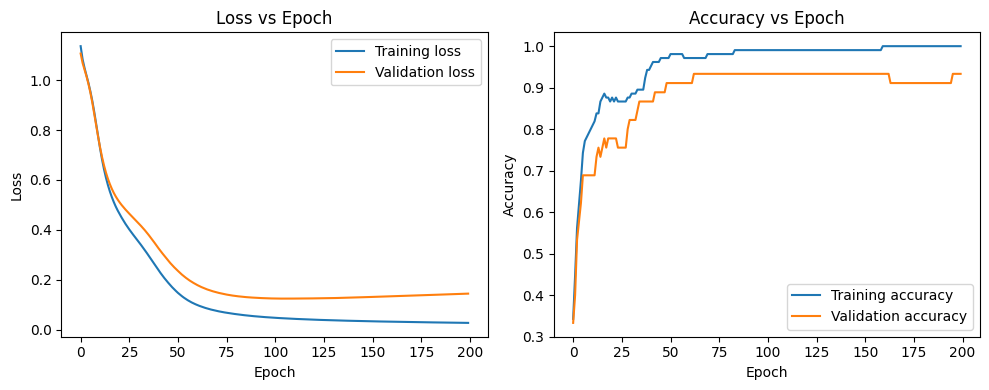

Training accuracy : 1.0000
Test accuracy     : 0.9333
Precision (macro)  : 0.9444
F1-score (macro)   : 0.9327
Final training loss   : 0.0269
Final validation loss : 0.1442

Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report
)

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP trained using Gradient Descent (SGD)
EPOCHS = 200

model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    batch_size=16,
    max_iter=1,
    warm_start=True,
    random_state=42
)

train_loss = []
val_loss = []
train_acc = []
val_acc = []

# Train one epoch at a time
for epoch in range(EPOCHS):
    model.fit(X_train, y_train)

    train_loss.append(model.loss_)

    val_loss.append(
        log_loss(
            y_test,
            model.predict_proba(X_test),
            labels=[0, 1, 2]
        )
    )

    train_acc.append(model.score(X_train, y_train))
    val_acc.append(model.score(X_test, y_test))

# Plot loss and accuracy
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(train_loss, label="Training loss")
ax[0].plot(val_loss, label="Validation loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].set_title("Loss vs Epoch")

ax[1].plot(train_acc, label="Training accuracy")
ax[1].plot(val_acc, label="Validation accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].set_title("Accuracy vs Epoch")

plt.tight_layout()
plt.show()

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Training accuracy : %.4f" % model.score(X_train, y_train))
print("Test accuracy     : %.4f" % accuracy_score(y_test, y_pred))

print("Precision (macro)  : %.4f" %
      precision_score(y_test, y_pred, average='macro'))

print("F1-score (macro)   : %.4f" %
      f1_score(y_test, y_pred, average='macro'))

print("Final training loss   : %.4f" % train_loss[-1])
print("Final validation loss : %.4f" % val_loss[-1])

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n",
      classification_report(
          y_test,
          y_pred,
          target_names=iris.target_names
      ))